<a href="https://colab.research.google.com/github/Thimo173/Ecogu/blob/main/ECOGU_Open_Innovation_Platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECOGU Open Innovation Platform

## Data-Driven Innovation Management for Sustainable Furniture Production

# Introduction

ECOGU Innovations is a sustainability-focused company that transforms waste materials such as plastic, wood, and paper into furniture products.

An innovation audit identified several challenges including:

- Lack of a structured idea management system
- No formal idea selection process
- Limited external stakeholder participation
- Weak innovation implementation processes

This notebook demonstrates how data analytics can support innovation management and idea evaluation within ECOGU.

In [1]:
import pandas as pd

data = {
    "idea_id":[1,2,3,4,5,6,7,8,9,10],
    "source":["Employee","Customer","Recycler","Designer","Employee",
              "Customer","Recycler","Designer","Employee","Customer"],
    "category":["Plastic","Wood","Paper","Plastic","Wood",
                "Paper","Plastic","Wood","Paper","Plastic"],
    "sustainability_score":[8,7,6,9,5,8,7,6,9,8],
    "feasibility_score":[7,8,5,9,6,7,8,5,9,8],
    "votes":[20,15,5,25,8,18,10,12,30,16],
    "selected":[1,1,0,1,0,1,0,0,1,1]
}

df = pd.DataFrame(data)

df

,idea_id,source,category,sustainability_score,feasibility_score,votes,selected
0,1,Employee,Plastic,8,7,20,1
1,2,Customer,Wood,7,8,15,1
2,3,Recycler,Paper,6,5,5,0
3,4,Designer,Plastic,9,9,25,1
4,5,Employee,Wood,5,6,8,0
5,6,Customer,Paper,8,7,18,1
6,7,Recycler,Plastic,7,8,10,0
7,8,Designer,Wood,6,5,12,0
8,9,Employee,Paper,9,9,30,1
9,10,Customer,Plastic,8,8,16,1


# Exploratory Data Analysis

This section explores the characteristics of innovation ideas submitted to ECOGU.

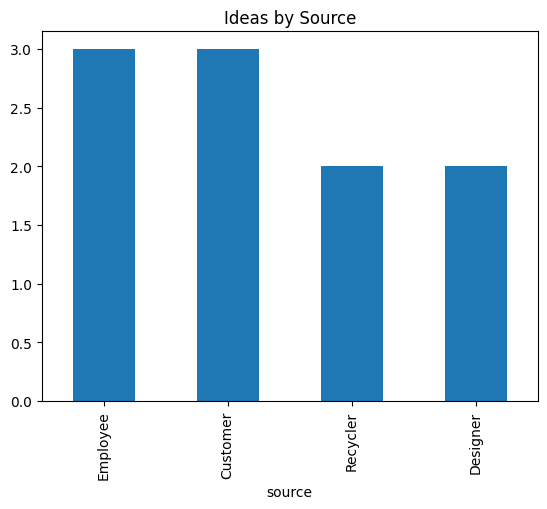

In [2]:
import matplotlib.pyplot as plt

df["source"].value_counts().plot(kind="bar")

plt.title("Ideas by Source")

plt.show()

### Interpretation

The chart shows participation from multiple stakeholder groups including employees, customers, recyclers, and designers.

This supports ECOGU's goal of encouraging open innovation and diverse idea generation.

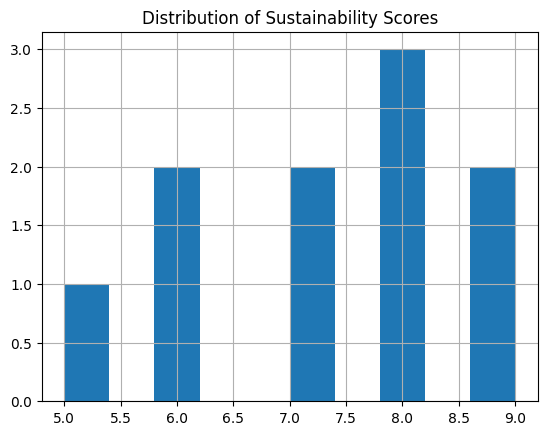

In [3]:
df["sustainability_score"].hist()

plt.title("Distribution of Sustainability Scores")

plt.show()

# Feature Engineering

To improve idea evaluation, an innovation score was created.

In [4]:
df["innovation_score"] = (
    df["sustainability_score"] * 0.5 +
    df["feasibility_score"] * 0.3 +
    df["votes"] * 0.2
)

df.head()

,idea_id,source,category,sustainability_score,feasibility_score,votes,selected,innovation_score
0,1,Employee,Plastic,8,7,20,1,10.1
1,2,Customer,Wood,7,8,15,1,8.9
2,3,Recycler,Paper,6,5,5,0,5.5
3,4,Designer,Plastic,9,9,25,1,12.2
4,5,Employee,Wood,5,6,8,0,5.9


# Predicting Idea Selection

A Logistic Regression model was used to predict whether an idea would be selected.

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df_ml = df.copy()

encoder = LabelEncoder()

df_ml["source"] = encoder.fit_transform(df_ml["source"])
df_ml["category"] = encoder.fit_transform(df_ml["category"])

X = df_ml.drop("selected", axis=1)
y = df_ml["selected"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


# Fairness Analysis Using AIF360

Innovation systems can unintentionally favor ideas from specific groups.

IBM AIF360 was considered as a fairness framework to evaluate whether employees, customers, recyclers, and designers receive equitable treatment during idea selection.

Using fairness assessment helps ensure transparency and inclusiveness within ECOGU's innovation process.

# Connection to the ECOGU MVP

The ECOGU Open Innovation Platform introduces:

- Idea submission
- Voting
- Commenting
- Stage-Gate workflow
- External stakeholder participation

These features directly address weaknesses identified during the innovation audit.

# Reflection

The MVP provides a structured process for collecting and managing innovation ideas.

Data analytics complements the MVP by supporting objective decision-making through idea evaluation and prediction.

Future developments could integrate machine learning and fairness monitoring directly into the platform to further improve innovation management.